In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

#scaling, normalization
from sklearn.preprocessing import StandardScaler, MinMaxScaler

#kmeans, dbscan, hierarchical (sklearn)
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
#evaluation
from sklearn.metrics import silhouette_score
#import dataset
from sklearn.datasets import load_iris

#distance matrix (dbscan elbow, hierarchical)
from scipy.spatial.distance import pdist, squareform

# hierarchical (scipy)
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [2]:
data = "data/output/02_data_understanding/clean_data_train.csv"
df = pd.read_csv(data)

In [3]:
# we use z-score normalization for the numerical features
# it is less sensitive to outliers

# only numerical columns are used for clustering
numCol = [
    "criticReviewsTotal",
    "numRegions",
    "numVotes",
    "runtimeMinutes",
    "totalCredits",
    "totalMedia",
    "totalRecognitions",
    "userReviewsTotal"
]

# scaler = StandardScaler()
# _df = df[numCol]
# df_Z = scaler.fit_transform(_df)

# min-max normalization
scaler = MinMaxScaler()
_df = df[numCol]
df_Z = scaler.fit_transform(_df)

# K-means

First of all we focus on choosing meaningful values of $k$. To do that we create two plots that shows silhouette and SSE for different values of $k$. The range choose is $[2;100]$

In [7]:
sse_list = []
sil_list = []
label_list = []

dist = squareform(pdist(df_Z, metric='euclidean'))

for k in range(2,30):
    kmeans = KMeans(n_clusters=k, init = 'k-means++',n_init = 100, random_state=42)
    kmeans.fit(df_Z)
    sse = kmeans.inertia_
    sil = silhouette_score(dist, kmeans.labels_, metric='precomputed')
    # print k, without newline
    print(k, end=' ') 
    sse_list.append(sse)
    sil_list.append(sil)
    label_list.append(k)

2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 

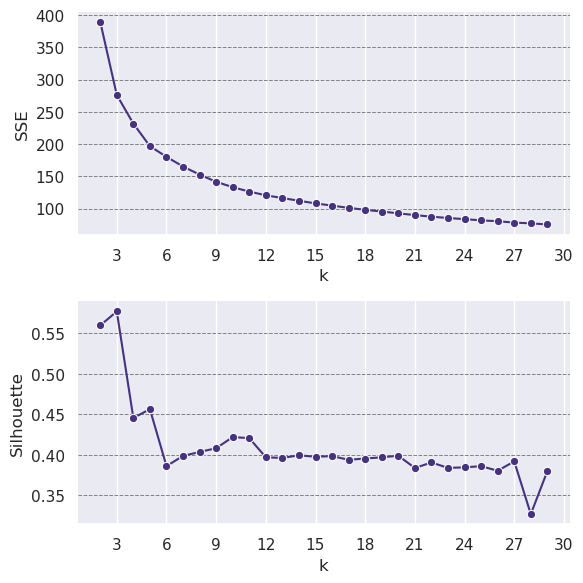

In [20]:
# Imposta il tema di Seaborn a viridis
sns.set_theme(palette='viridis')

# Crea i subplot
fig, axs = plt.subplots(2, figsize=(6, 6))

# Plot SSE
sns.lineplot(x=label_list, y=sse_list, marker='o', ax=axs[0])
axs[0].set(xlabel='k', ylabel='SSE')

# Plot Silhouette
sns.lineplot(x=label_list, y=sil_list, marker='o', ax=axs[1])
axs[1].set(xlabel='k', ylabel='Silhouette')

# Configura gli assi
for ax in axs:
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))  # Mostra solo numeri interi sull'asse x
    ax.grid(True, which='both', axis='y', color='gray', linestyle='--', linewidth=0.7)  # Linee grigio chiaro solo sull'asse y
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

plt.tight_layout()  # Adjust the padding between and around subplots
plt.show()

In [25]:
# k = 11
N = 100
sse_stats = []

for _ in range(N):
    Xi = np.zeros(shape=df_Z.shape)
    
    for cidx in range(Xi.shape[1]):
        print(f'\rIteration: {_+1}/{N}', end=' ')
        col = df_Z[:, cidx]
        min, max, nor = np.min(col), np.max(col), len(col)
        Xi[:, cidx] = np.random.uniform(min, max, (1, nor))
    
    kmeans = KMeans(n_clusters=11, n_init=10, max_iter=30, random_state=42)
    kmeans.fit(Xi)
    sse_stats.append(kmeans.inertia_)

Iteration: 100/100 

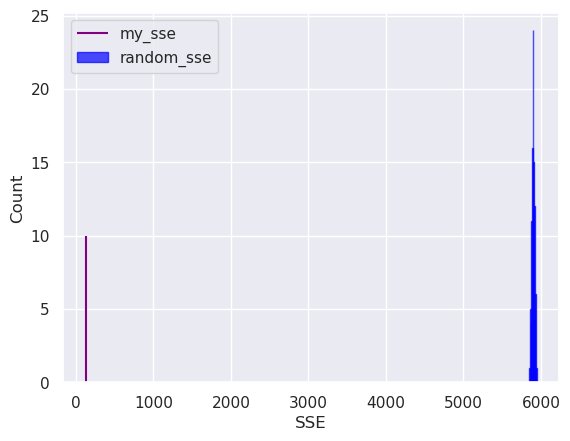

In [26]:
# k = 11
plt.vlines(x = sse_list[9], ymin = 0, ymax = 10, colors = 'purple', label = 'my_sse')
plt.hist(sse_stats, bins='auto', alpha=0.7, color='blue', edgecolor='blue', label='random_sse')

plt.xlabel('SSE')
plt.ylabel('Count')
plt.legend()
plt.show()

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

def load_labels_from_txt(txt_path):
    """
    Carica le etichette da un file di testo.

    Args:
        txt_path (str): Il percorso del file di testo.

    Returns:
        dict: Un dizionario con le etichette mappate.
    """
    labels = {}
    with open(txt_path, 'r') as file:
        for line in file:
            key, value = line.strip().split(': ')
            labels[int(value)] = key
    return labels

def plot_kmeans_clusters(df, k, y_mapped, txt_path = "./encoding_lists/titleType.txt", remove_column=None, n_init=100, max_iter=100, random_state=42):
    """
    Esegue il clustering KMeans per un singolo valore di k e traccia i centri dei cluster.

    Parameters:
    df (DataFrame): Il DataFrame contenente i dati.
    k (int): Il numero di cluster per il clustering KMeans.
    y_mapped (Series): Serie contenente le etichette mappate.
    txt_path (str): Il percorso del file di testo contenente le etichette.
    remove_column (str): Nome della colonna da rimuovere dal grafico.
    n_init (int): Numero di inizializzazioni per KMeans.
    max_iter (int): Numero massimo di iterazioni per KMeans.
    random_state (int): Stato casuale per la riproducibilità.
    """
    # Carica le etichette dal file di testo
    labels_dict = load_labels_from_txt(txt_path)

    # Normalizza i dati
    scaler = MinMaxScaler()
    df_scaled = scaler.fit_transform(df)
    
    kmeans = KMeans(n_clusters=k, n_init=n_init, max_iter=max_iter, random_state=random_state)
    kmeans.fit(df_scaled)
    centers = scaler.inverse_transform(kmeans.cluster_centers_)
    
    # Aggiungi le etichette dei cluster al DataFrame
    df['kmeans_labels'] = kmeans.labels_
    
    # Imposta la dimensione dinamica in base al numero di colonne
    fig_width = len(df.columns) * 1  # Dimensione dinamica
    fig_height = 4 # Altezza fissa per uniformare le dimensioni tra i grafici
    
    # Primo grafico: Centri dei cluster
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    clust_name = [chr(65 + i) for i in range(k)]  # Genera nomi di cluster A, B, C, ...
    
    # Plot dei centri dei cluster
    for i in range(len(centers)):
        ax.plot(centers[i], marker='o', label=clust_name[i])
    
    ax.set_xticks(range(0, len(df.columns) - 1))
    ax.set_xticklabels(df.columns[:-1], fontsize=13)
    ax.tick_params(axis='y', labelsize=13)
    ax.set_title(f'KMeans Clustering with k={k} (All Columns)')
    ax.grid(axis='y')

    # Ruota le etichette di 45 gradi
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')  # Allinea a destra
    
    # Legenda separata a destra
    ax.legend(fontsize=13, loc='upper left', bbox_to_anchor=(1, 1))  # Aggiungi la legenda separata
    plt.show()
    
    # Secondo grafico: Centri dei cluster senza la colonna specificata
    if remove_column and remove_column in df.columns:
        fig, ax = plt.subplots(figsize=(fig_width, fig_height))
        
        # Elimina la colonna da rimuovere e 'kmeans_labels' dai dati da tracciare
        columns_to_plot = df.drop(columns=[remove_column, 'kmeans_labels']).columns
        
        for i in range(len(centers)):
            centers_to_plot = np.delete(centers[i], df.columns.get_loc(remove_column))  # Rimuovi la colonna dai centri
            ax.plot(centers_to_plot, marker='o', label=clust_name[i])
        
        ax.set_xticks(range(0, len(columns_to_plot)))
        ax.set_xticklabels(columns_to_plot, fontsize=13)
        ax.tick_params(axis='y', labelsize=13)
        ax.set_title(f'KMeans Clustering with k={k} (Without {remove_column})')
        ax.grid(axis='y')
        
        # Ruota le etichette di 45 gradi
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_ha('right')  # Allinea a destra
        
        # Legenda separata a destra
        ax.legend(fontsize=13, loc='upper left', bbox_to_anchor=(1, 1))  # Aggiungi la legenda separata
        plt.show()

    # Terzo grafico: Distribuzione delle etichette di cluster
    bar_pl = y_mapped.groupby(df['kmeans_labels']).value_counts(normalize=True).unstack(1)
    bar_pl = bar_pl.rename(columns=labels_dict)  # Rinomina le colonne utilizzando le etichette dal file di testo
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    bar_pl.plot(kind='bar', stacked=True, alpha=0.9, edgecolor='white', linewidth=1.5, ax=ax)
    
    ax.set_xticks(range(0, len(clust_name)))
    ax.set_xticklabels(clust_name, fontsize=13)
    ax.tick_params(axis='y', labelsize=13)
    ax.legend(bbox_to_anchor=(1, 1))
    ax.set_ylabel('Number of elements by titleType')
    ax.set_title('Distribution of Cluster Labels')
    
    plt.show()
    
    # Quarto grafico: Numero di elementi in ciascun cluster raggruppati per y_mapped
    cluster_counts = df.groupby(['kmeans_labels', y_mapped]).size().unstack().fillna(0)
    cluster_counts = cluster_counts.rename(columns=labels_dict)  # Rinomina le colonne utilizzando le etichette dal file di testo
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    cluster_counts.plot(kind='bar', stacked=True, alpha=0.9, edgecolor='white', linewidth=1.5, ax=ax)
    
    ax.set_xticks(range(0, len(clust_name)))
    ax.set_xticklabels(clust_name, fontsize=13)
    ax.tick_params(axis='y', labelsize=13)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Number of Elements')
    ax.set_title(f'Number of Elements in Each Cluster Grouped by {y_mapped.name}')
    ax.legend(title=y_mapped.name, bbox_to_anchor=(1, 1))
    
    plt.show()


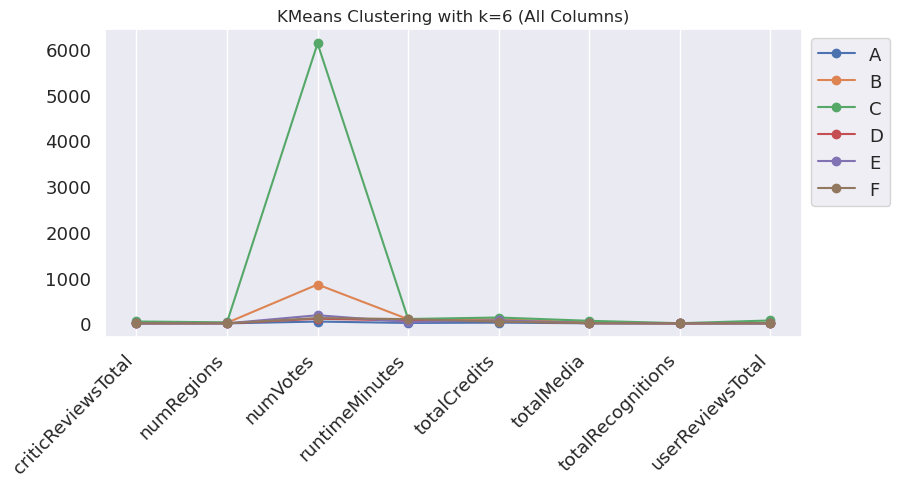

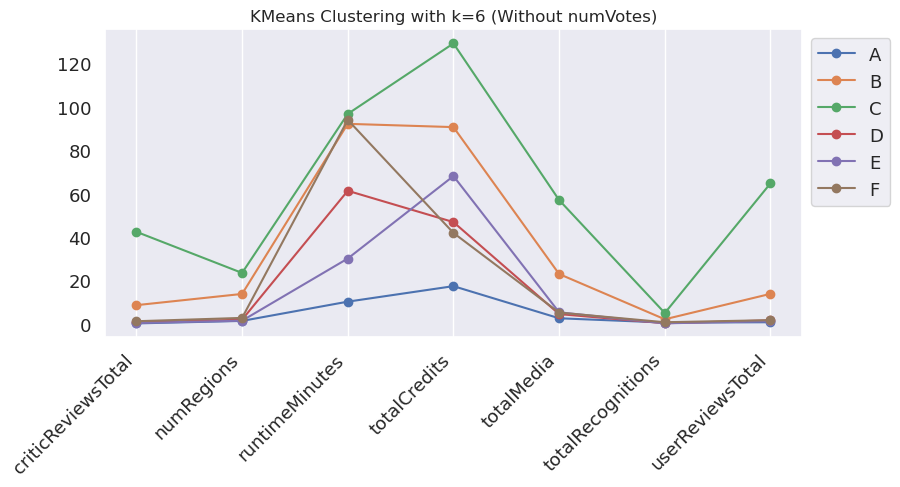

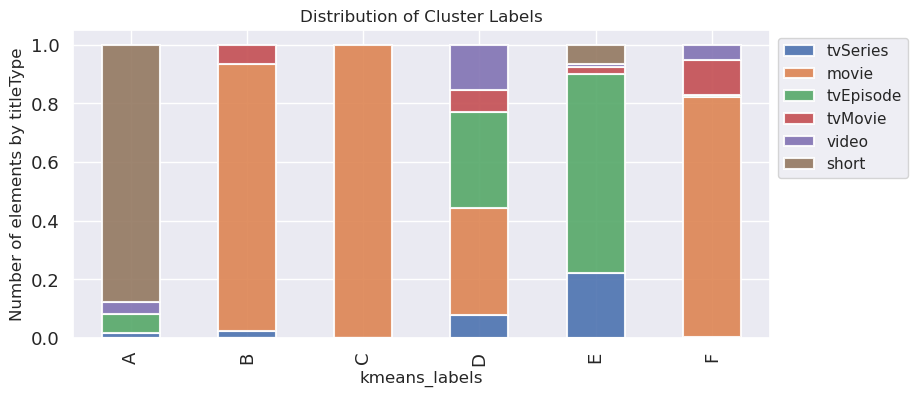

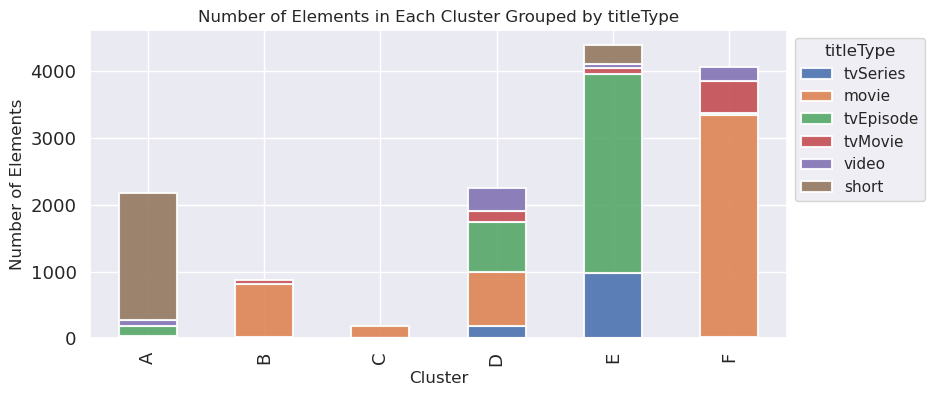

In [94]:

col = 'titleType'

# col = 'rating'

plot_kmeans_clusters(_df[numCol], 6, df[col], remove_column='numVotes')

/tmp/ipykernel_3886/378416682.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['kmeans_labels'] = kmeans.labels_


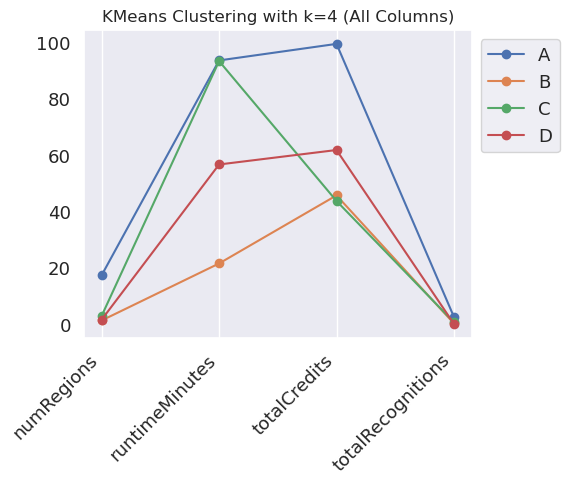

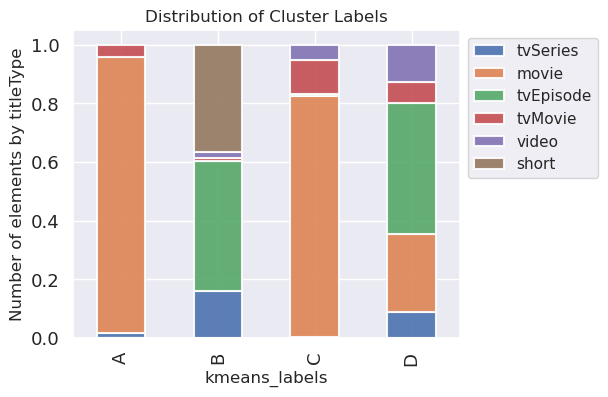

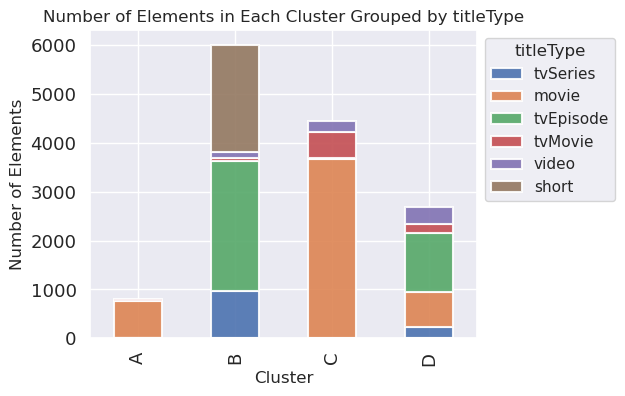

/tmp/ipykernel_3886/378416682.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['kmeans_labels'] = kmeans.labels_


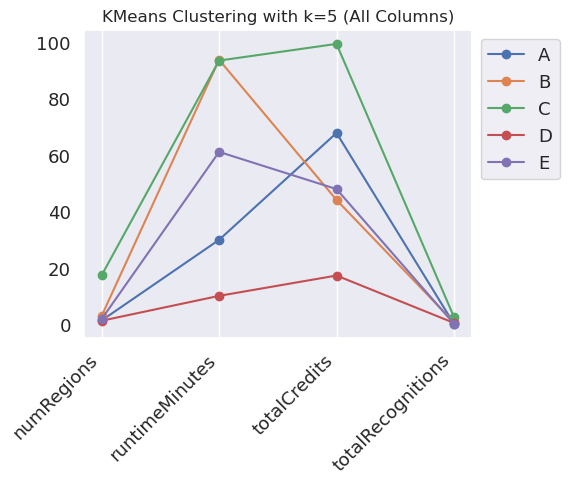

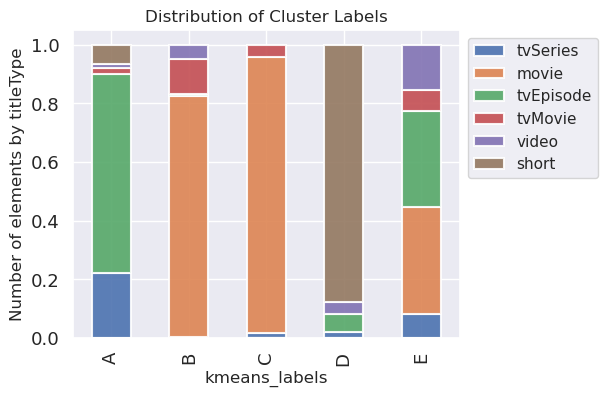

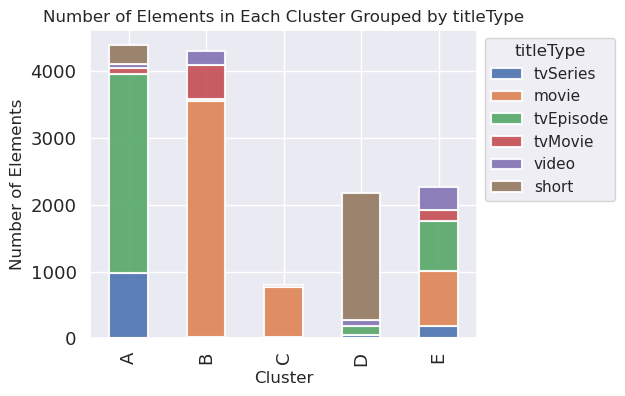

/tmp/ipykernel_3886/378416682.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['kmeans_labels'] = kmeans.labels_


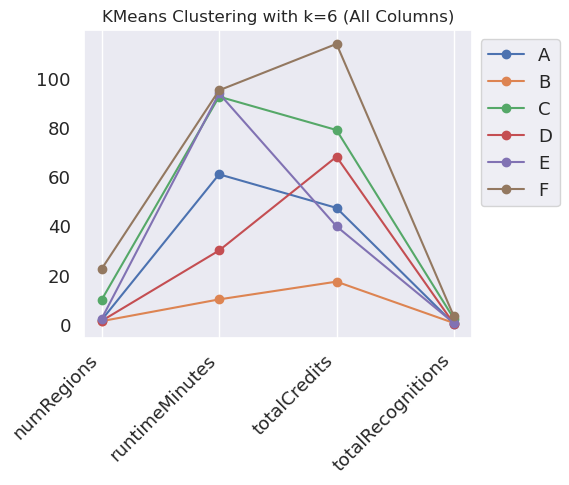

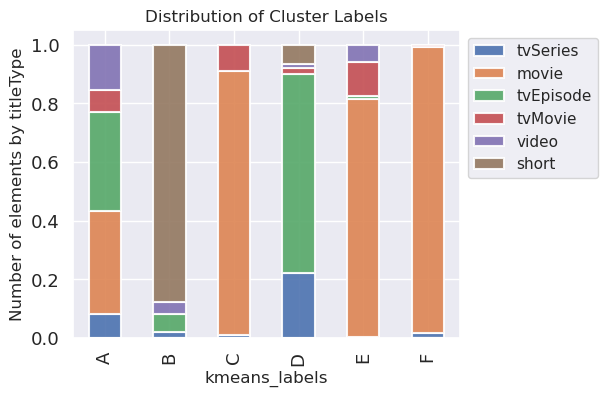

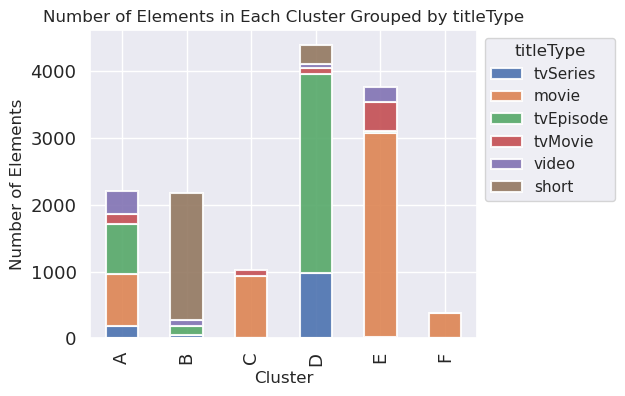

In [7]:
sns.set_theme()
numCol = [
# "criticReviewsTotal",
    "numRegions",
#   "numVotes",
  "runtimeMinutes",
  "totalCredits",
#  "totalMedia",
   "totalRecognitions",
# "userReviewsTotal"
]
col = 'titleType'

# col = 'rating'

plot_kmeans_clusters(_df[numCol], 4, df[col])

plot_kmeans_clusters(_df[numCol], 5, df[col])

plot_kmeans_clusters(_df[numCol], 6, df[col])


In [9]:
sse_list = []
sil_list = []
label_list = []

_df = df[numCol]
df_Z = scaler.fit_transform(_df)

dist = squareform(pdist(df_Z, metric='euclidean'))

for k in range(2,30):
    kmeans = KMeans(n_clusters=k, init = 'k-means++',n_init = 50, random_state=42)
    kmeans.fit(df_Z)
    sse = kmeans.inertia_
    sil = silhouette_score(dist, kmeans.labels_, metric='precomputed')
    # print k, without newline
    print(k, end=' ') 
    sse_list.append(sse)
    sil_list.append(sil)
    label_list.append(k)

2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 

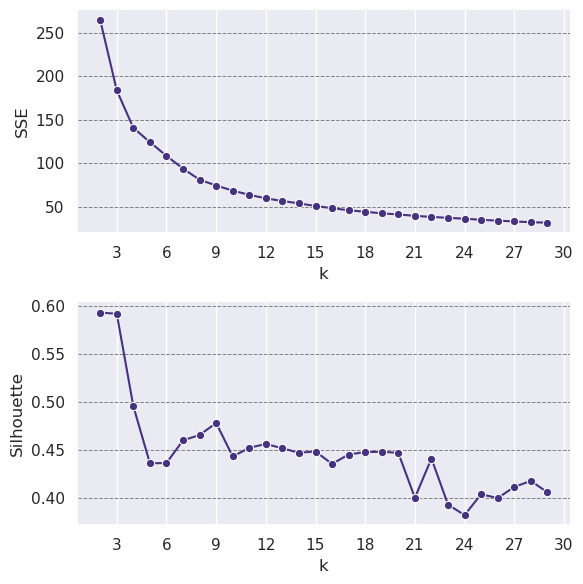

In [10]:
# Imposta il tema di Seaborn a viridis
sns.set_theme(palette='viridis')

# Crea i subplot
fig, axs = plt.subplots(2, figsize=(6, 6))

# Plot SSE
sns.lineplot(x=label_list, y=sse_list, marker='o', ax=axs[0])
axs[0].set(xlabel='k', ylabel='SSE')

# Plot Silhouette
sns.lineplot(x=label_list, y=sil_list, marker='o', ax=axs[1])
axs[1].set(xlabel='k', ylabel='Silhouette')

# Configura gli assi
for ax in axs:
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))  # Mostra solo numeri interi sull'asse x
    ax.grid(True, which='both', axis='y', color='gray', linestyle='--', linewidth=0.7)  # Linee grigio chiaro solo sull'asse y
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

plt.tight_layout()  # Adjust the padding between and around subplots
plt.show()

# X-means
We decided to use X-means and not bisecting K-means because we wanted to see if gives bettere results than simple K-means which didn't give good results and no information were discovered.

In [12]:
# import PCA
from sklearn.decomposition import PCA
from pyclustering.cluster import xmeans

In [192]:

numCol = [
    "criticReviewsTotal",
    "numRegions",
    "numVotes",
    "runtimeMinutes",
    "totalCredits",
    "totalMedia",
    "totalRecognitions",
    "userReviewsTotal"
]

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df[numCol])



# scaler = MinMaxScaler()
# _df = df[numCol]
# df_Z = scaler.fit_transform(_df)


xm = xmeans.xmeans(df_pca, kmax = 50, repeat = 500)
xm.process()
centers = np.array(xm.get_centers())

len_centers = len(centers)
print(f'Number of clusters: {len_centers}')

Number of clusters: 35


In [13]:
from sklearn.cluster import BisectingKMeans
from yellowbrick.cluster import SilhouetteVisualizer

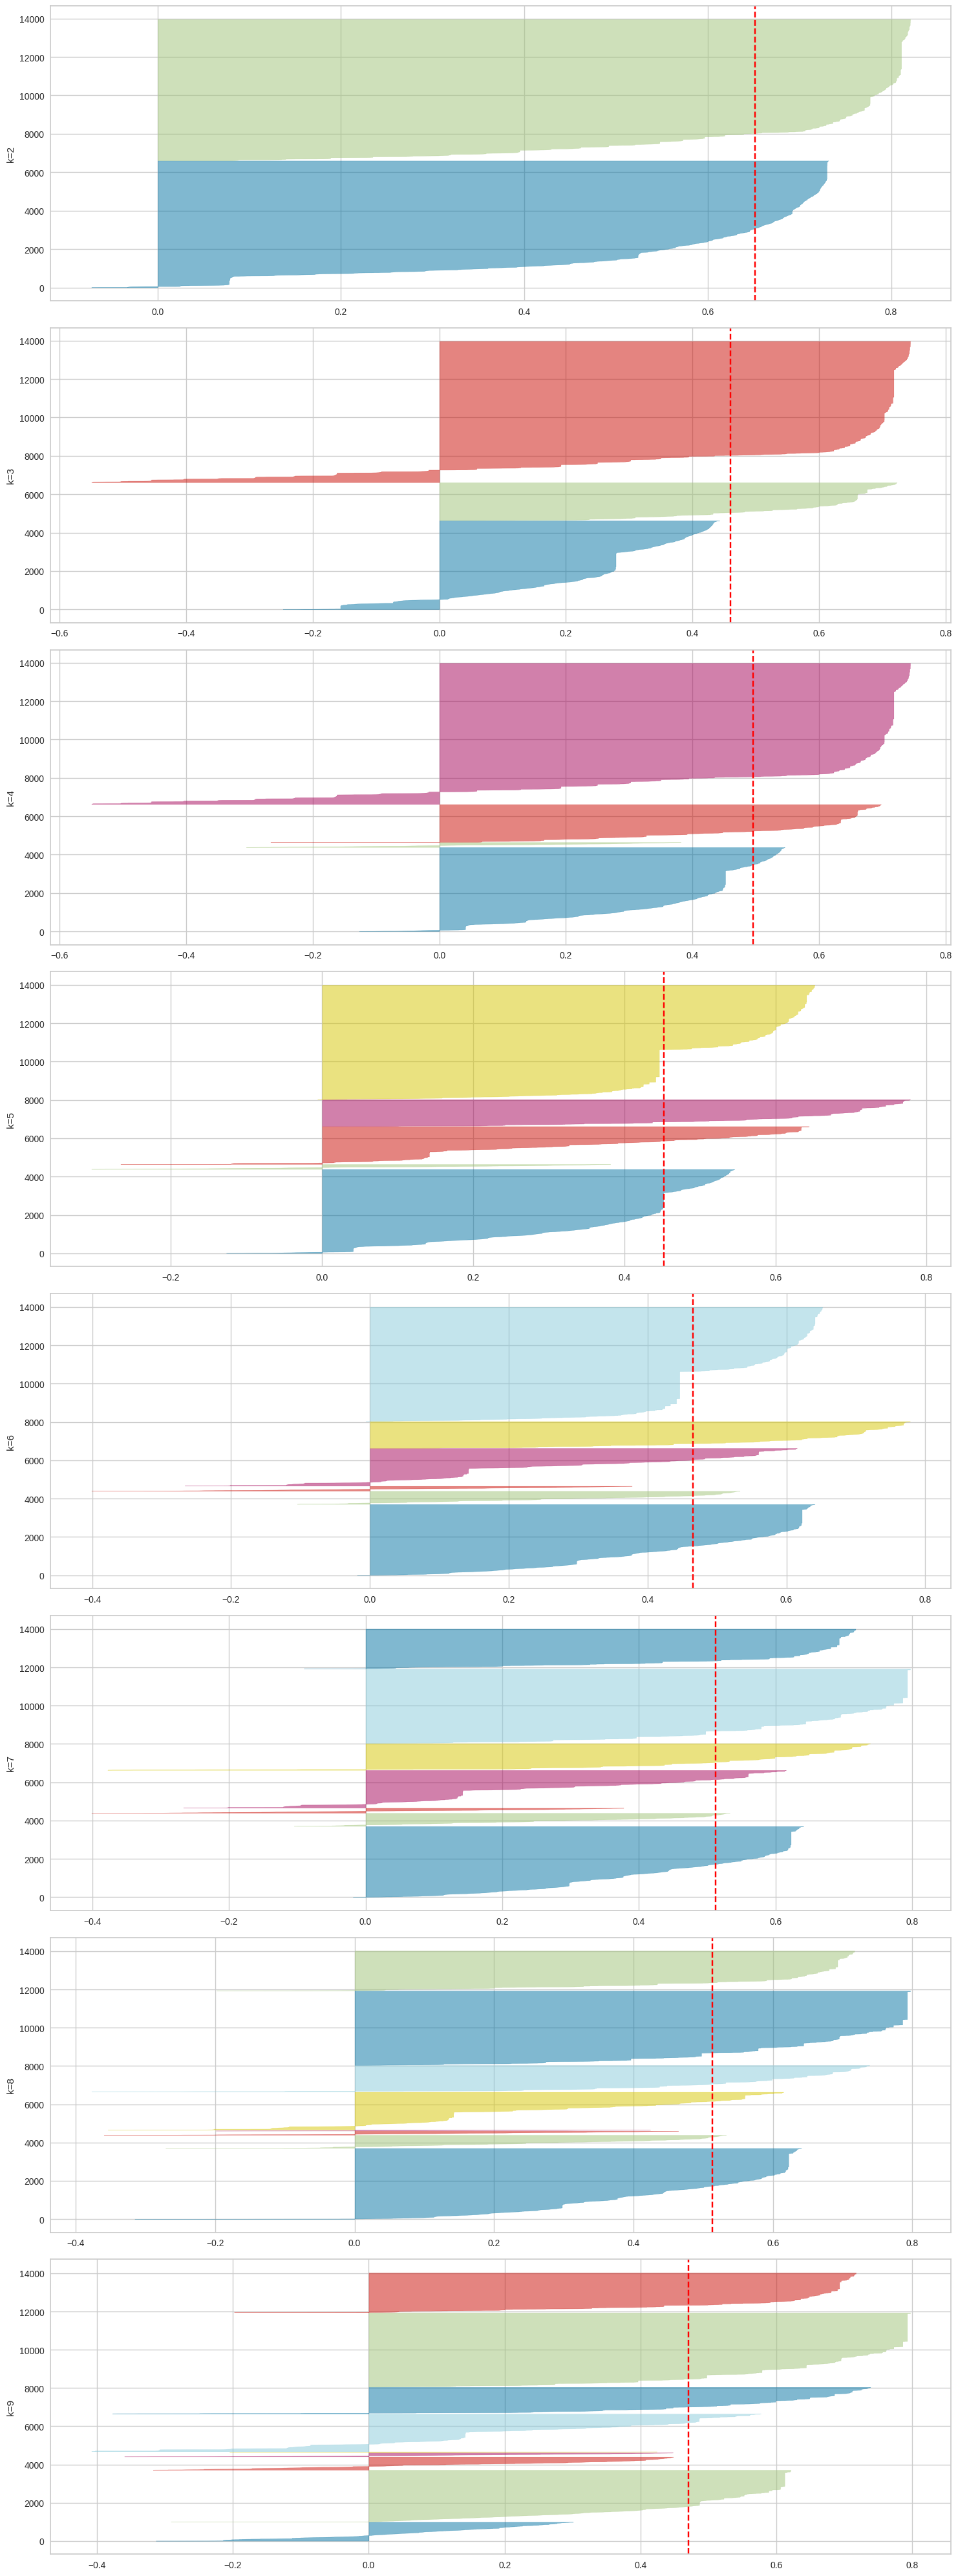

In [45]:
# Min-max normalization
scaler = MinMaxScaler()
_df = df[numCol]
df_Z = scaler.fit_transform(_df)

# Configura i colori e il numero di cluster
colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']
n_clust = 10
fig, axs = plt.subplots(n_clust-2, 1, figsize=(15, 5 * (n_clust-2)))

for i in range(2, n_clust):
    # Esegui Bisecting KMeans
    bkmeans = BisectingKMeans(n_clusters=i, random_state=42)
    bkmeans.fit(df_Z)
    
    # Visualizza il Silhouette Plot
    visualizer = SilhouetteVisualizer(bkmeans, colors=colors, ax=axs[i-2])
    axs[i-2].set_ylabel("k=" + str(i))
    visualizer.fit(df_Z)


plt.tight_layout()
plt.show()

2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 

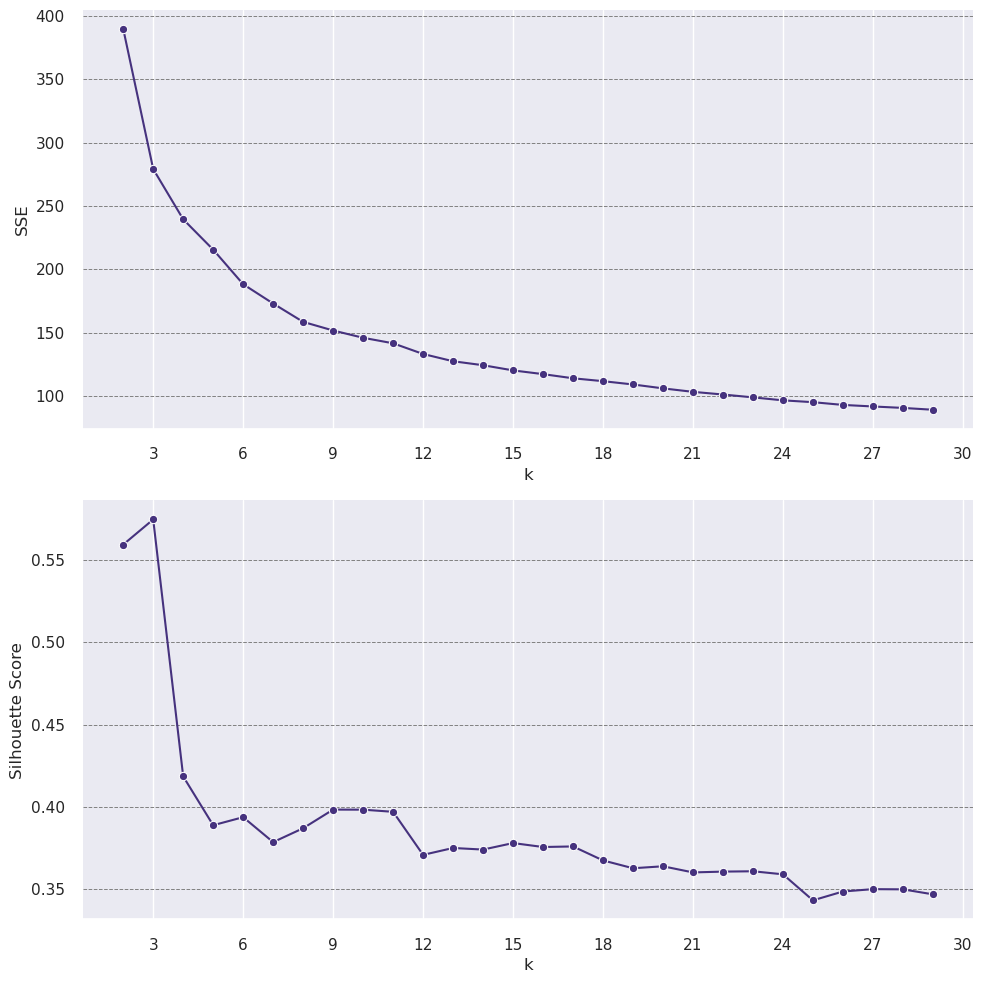

In [22]:
sns.set_theme(palette='viridis')


numCol = [
    "criticReviewsTotal",
    "numRegions",
    "numVotes",
    "runtimeMinutes",
    "totalCredits",
    "totalMedia",
    "totalRecognitions",
    "userReviewsTotal"
]

# Min-max normalization
scaler = MinMaxScaler()
_df = df[numCol]
df_Z = scaler.fit_transform(_df)

# Liste per memorizzare SSE, Silhouette Score e numero di cluster
sse_list = []
sil_list = []
label_list = []

# Calcola la matrice delle distanze
dist = squareform(pdist(df_Z, metric='euclidean'))

# Esegui Bisecting KMeans per diversi valori di k
for k in range(2, 30):
    bkmeans = BisectingKMeans(n_clusters=k, init = 'k-means++', n_init=500, random_state=42)
    bkmeans.fit(df_Z)
    sse = bkmeans.inertia_
    sil = silhouette_score(dist, bkmeans.labels_, metric='precomputed')
    # print k, without newline
    print(k, end=' ') 
    sse_list.append(sse)
    sil_list.append(sil)
    label_list.append(k)

# Visualizza i risultati
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Plot SSE
sns.lineplot(x=label_list, y=sse_list, marker='o', ax=axs[0])
axs[0].set(xlabel='k', ylabel='SSE')

# Plot Silhouette Score
sns.lineplot(x=label_list, y=sil_list, marker='o', ax=axs[1])
axs[1].set(xlabel='k', ylabel='Silhouette Score')

# Configura gli assi
for ax in axs:
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))  # Mostra solo numeri interi sull'asse x
    ax.grid(True, which='both', axis='y', color='gray', linestyle='--', linewidth=0.7)  # Linee grigio chiaro solo sull'asse y
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import BisectingKMeans

def load_labels_from_txt(txt_path):
    """
    Carica le etichette da un file di testo.

    Args:
        txt_path (str): Il percorso del file di testo.

    Returns:
        dict: Un dizionario con le etichette mappate.
    """
    labels = {}
    with open(txt_path, 'r') as file:
        for line in file:
            key, value = line.strip().split(': ')
            labels[int(value)] = key
    return labels

def plot_bisecting_kmeans_clusters(df, k, y_mapped, txt_path="./encoding_lists/titleType.txt", remove_column=None, n_init=100, max_iter=100, random_state=42):
    """
    Esegue il clustering Bisecting KMeans per un singolo valore di k e traccia i centri dei cluster.

    Parameters:
    df (DataFrame): Il DataFrame contenente i dati.
    k (int): Il numero di cluster per il clustering Bisecting KMeans.
    y_mapped (Series): Serie contenente le etichette mappate.
    txt_path (str): Il percorso del file di testo contenente le etichette.
    remove_column (str): Nome della colonna da rimuovere dal grafico.
    n_init (int): Numero di inizializzazioni per Bisecting KMeans.
    max_iter (int): Numero massimo di iterazioni per Bisecting KMeans.
    random_state (int): Stato casuale per la riproducibilità.
    """
    # Carica le etichette dal file di testo
    labels_dict = load_labels_from_txt(txt_path)

    # Normalizza i dati
    scaler = MinMaxScaler()
    df_scaled = scaler.fit_transform(df)
    
    bkmeans = BisectingKMeans(n_clusters=k, n_init = 100, random_state=random_state)
    bkmeans.fit(df_scaled)
    centers = scaler.inverse_transform(bkmeans.cluster_centers_)
    
    # Aggiungi le etichette dei cluster al DataFrame
    df['bkmeans_labels'] = bkmeans.labels_
    
    # Plot con tutte le colonne
    plt.figure(figsize=(10, 3))
    clust_name = [chr(65 + i) for i in range(k)]  # Genera nomi di cluster A, B, C, ...
    
    for i in range(len(centers)):
        plt.plot(centers[i], marker='o', label=clust_name[i])
    
    plt.xticks(range(0, len(df.columns) - 1), df.columns[:-1], fontsize=13)
    plt.yticks(fontsize=13)
    plt.xticks(rotation=90)
    plt.legend(fontsize=13, loc='best')
    plt.grid(axis='y')
    plt.title(f'Bisecting KMeans Clustering with k={k} (All Columns)')
    plt.show()
    
    # Plot senza la colonna specificata
    if remove_column and remove_column in df.columns:
        plt.figure(figsize=(10, 3))
        col_index = df.columns.get_loc(remove_column)
        columns_to_plot = df.columns.delete(col_index)
        
        for i in range(len(centers)):
            centers_to_plot = np.delete(centers[i], col_index)
            plt.plot(centers_to_plot, marker='o', label=clust_name[i])
        
        plt.xticks(range(0, len(columns_to_plot)), columns_to_plot, fontsize=13)
        plt.yticks(fontsize=13)
        plt.xticks(rotation=90)
        plt.legend(fontsize=13, loc='best')
        plt.grid(axis='y')
        plt.title(f'Bisecting KMeans Clustering with k={k} (Without {remove_column})')
        plt.show()
    
    # Plot della distribuzione delle etichette di cluster
    bar_pl = y_mapped.groupby(df['bkmeans_labels']).value_counts(normalize=True).unstack(1)
    bar_pl = bar_pl.rename(columns=labels_dict)  # Rinomina le colonne utilizzando le etichette dal file di testo
    bar_pl.plot(kind='bar', stacked=True, alpha=0.9, edgecolor='white', linewidth=1.5)
    
    plt.xticks(range(0, len(clust_name)), clust_name, fontsize=13, rotation=0)
    plt.yticks(fontsize=13)
    plt.legend(bbox_to_anchor=(1, 1))
    plt.title('Distribution of Cluster Labels')
    plt.show()
    
    # Plot del numero di elementi in ciascun cluster raggruppati per y_mapped
    cluster_counts = df.groupby(['bkmeans_labels', y_mapped]).size().unstack().fillna(0)
    cluster_counts = cluster_counts.rename(columns=labels_dict)  # Rinomina le colonne utilizzando le etichette dal file di testo
    cluster_counts.plot(kind='bar', stacked=True, alpha=0.9, edgecolor='white', linewidth=1.5, figsize=(10, 6))
    
    plt.xticks(range(0, len(clust_name)), clust_name, fontsize=13, rotation=0)
    plt.yticks(fontsize=13)
    plt.xlabel('Cluster')
    plt.ylabel('Number of Elements')
    plt.title(f'Number of Elements in Each Cluster Grouped by {y_mapped.name}')
    plt.legend(title=y_mapped.name, bbox_to_anchor=(1, 1))
    plt.show()

# Esempio di utilizzo
# df_Z = ...  # Definisci il tuo DataFrame
# y_mapped = ...  # Definisci la tua Serie contenente le etichette mappate
# k = 4  # Specifica il valore di k
# txt_path = '/path/to/titleType.txt'  # Specifica il percorso del file di testo
# plot_bisecting_kmeans_clusters(df_Z, k, y_mapped, txt_path, remove_column='column_name')

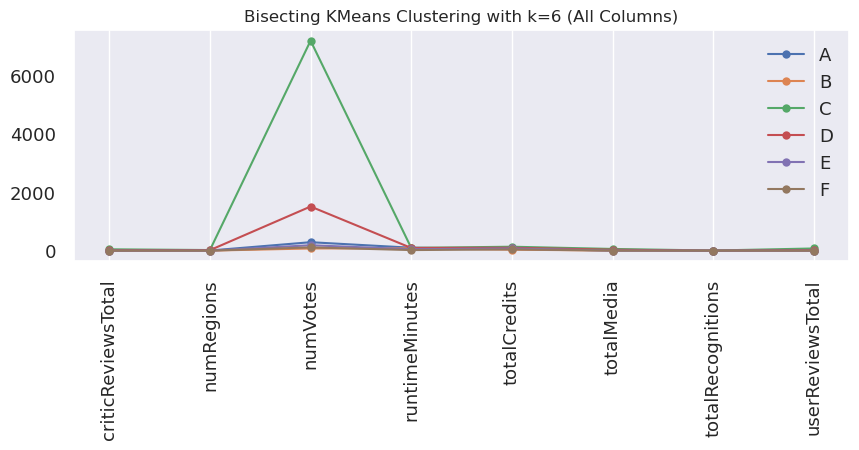

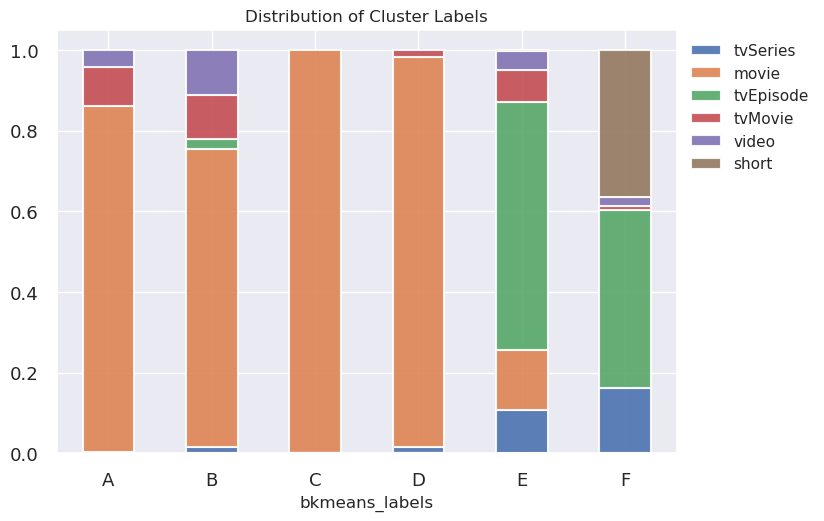

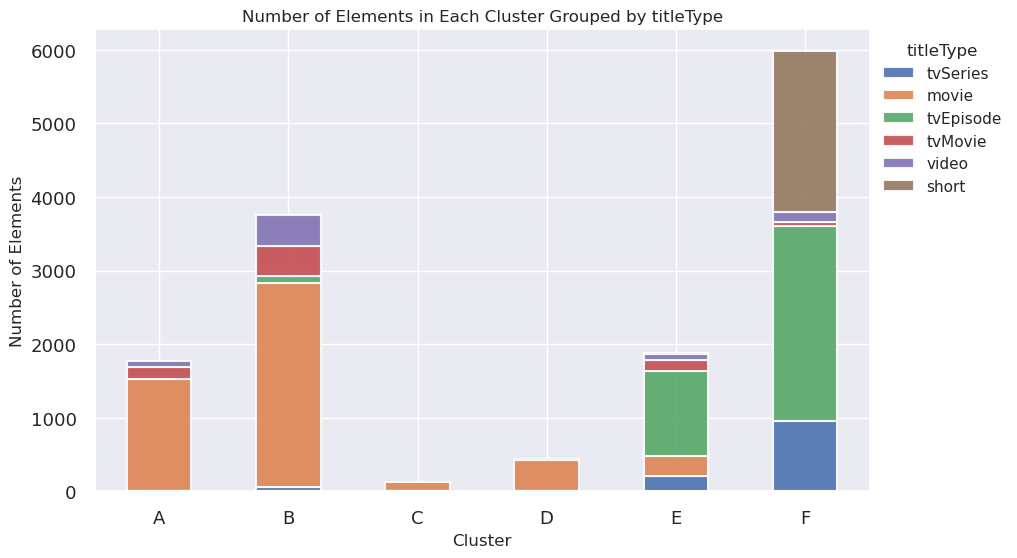

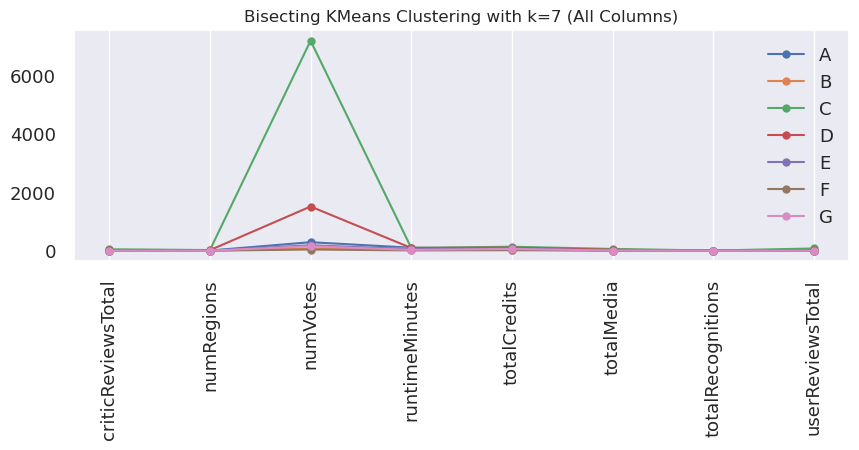

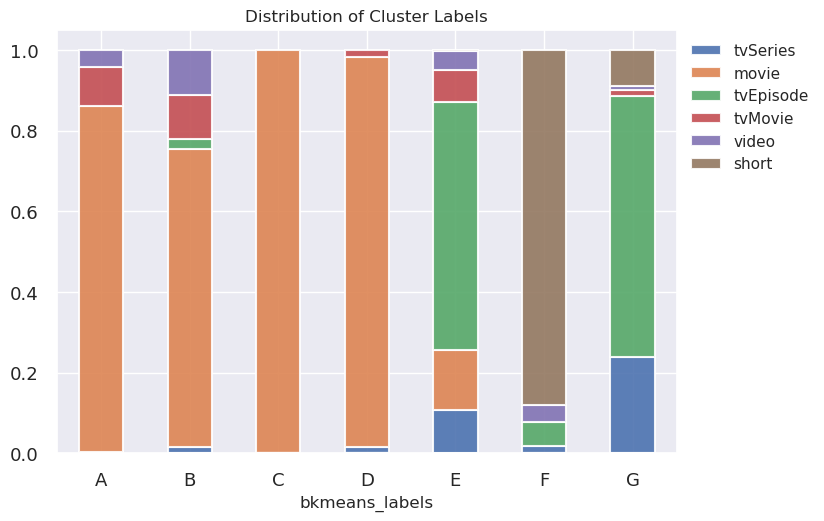

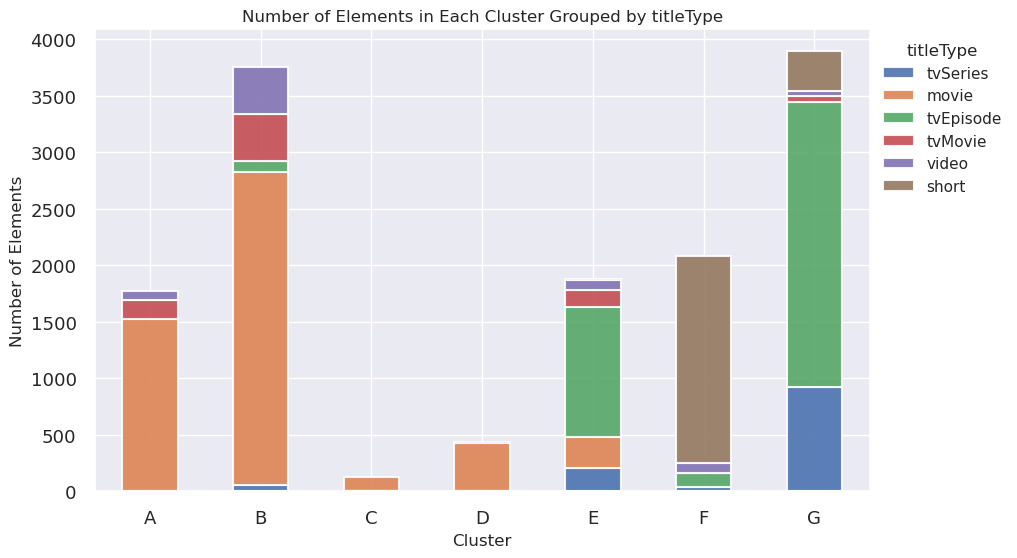

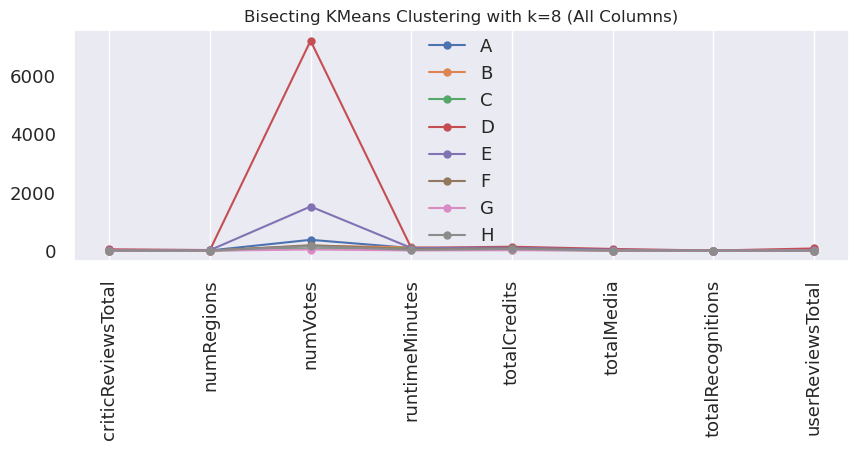

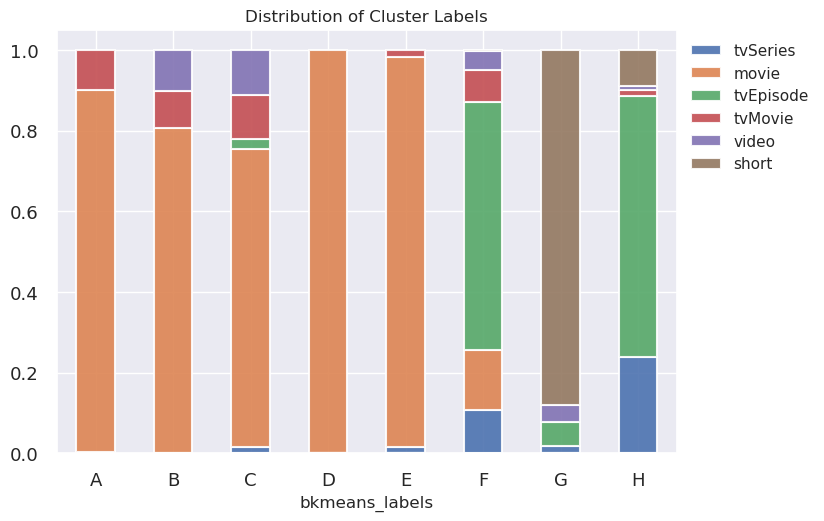

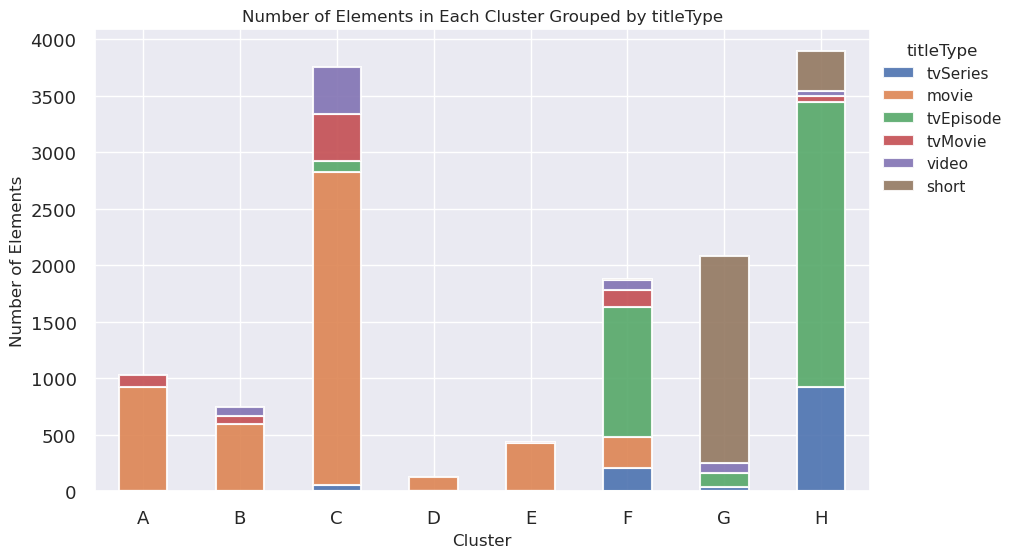

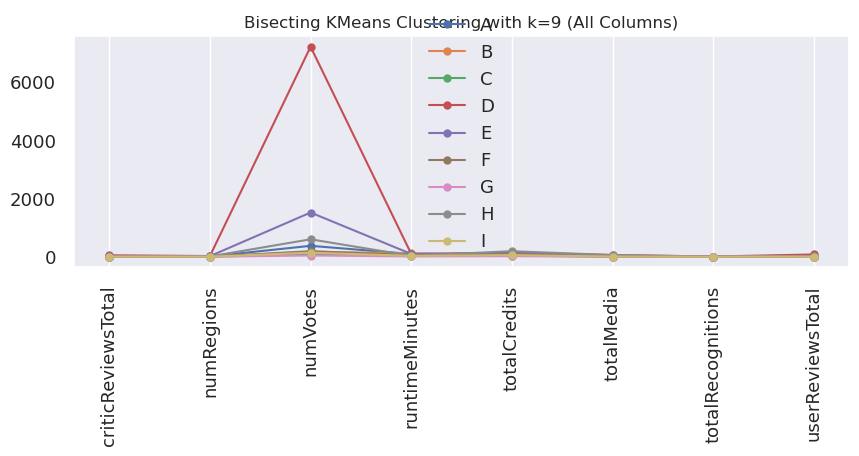

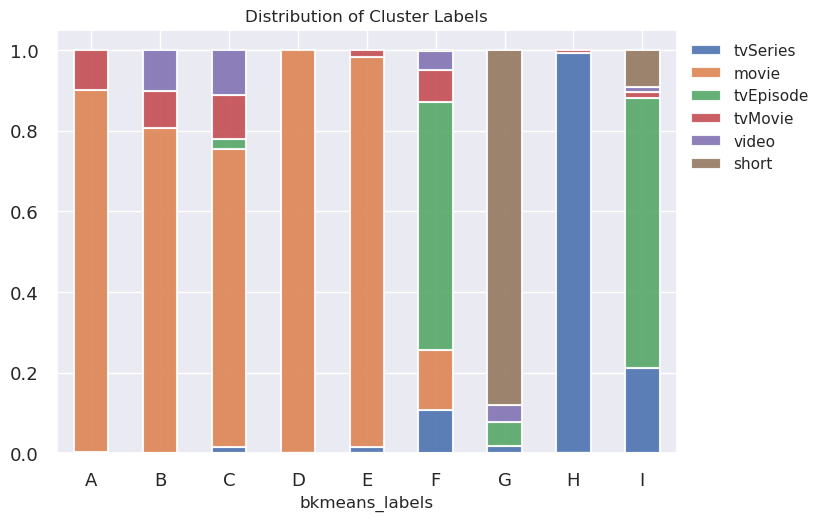

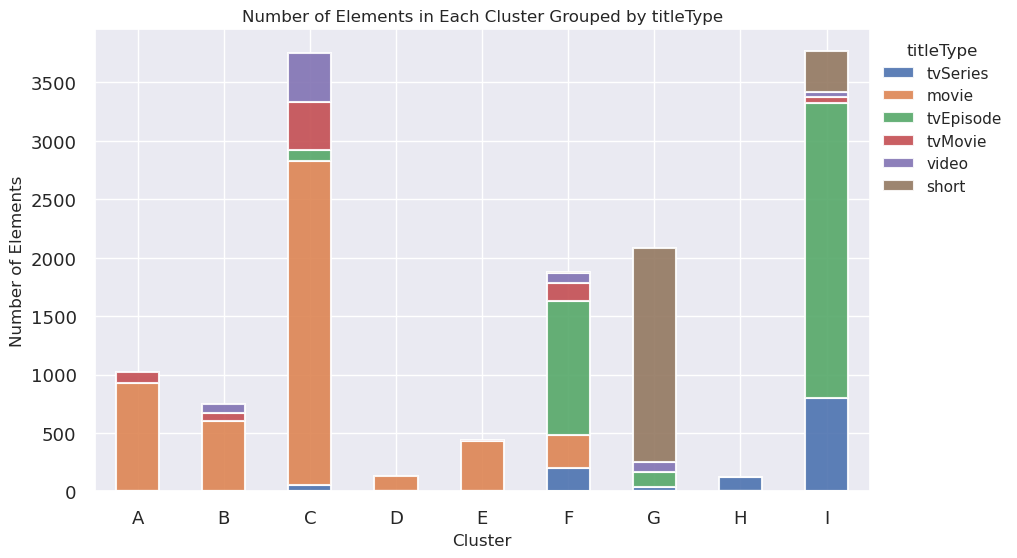

In [25]:
sns.set_theme()
numCol = [
    "criticReviewsTotal",
    "numRegions",
    "numVotes",
    "runtimeMinutes",
    "totalCredits",
    "totalMedia",
    "totalRecognitions",
    "userReviewsTotal"
]

col = 'titleType'

# Min-max normalization
scaler = MinMaxScaler()
_df = df[numCol]
df_Z = scaler.fit_transform(_df)

plot_bisecting_kmeans_clusters(_df[numCol], 6, df[col])

plot_bisecting_kmeans_clusters(_df[numCol], 7, df[col])

plot_bisecting_kmeans_clusters(_df[numCol], 8, df[col])

plot_bisecting_kmeans_clusters(_df[numCol], 9, df[col])

2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 

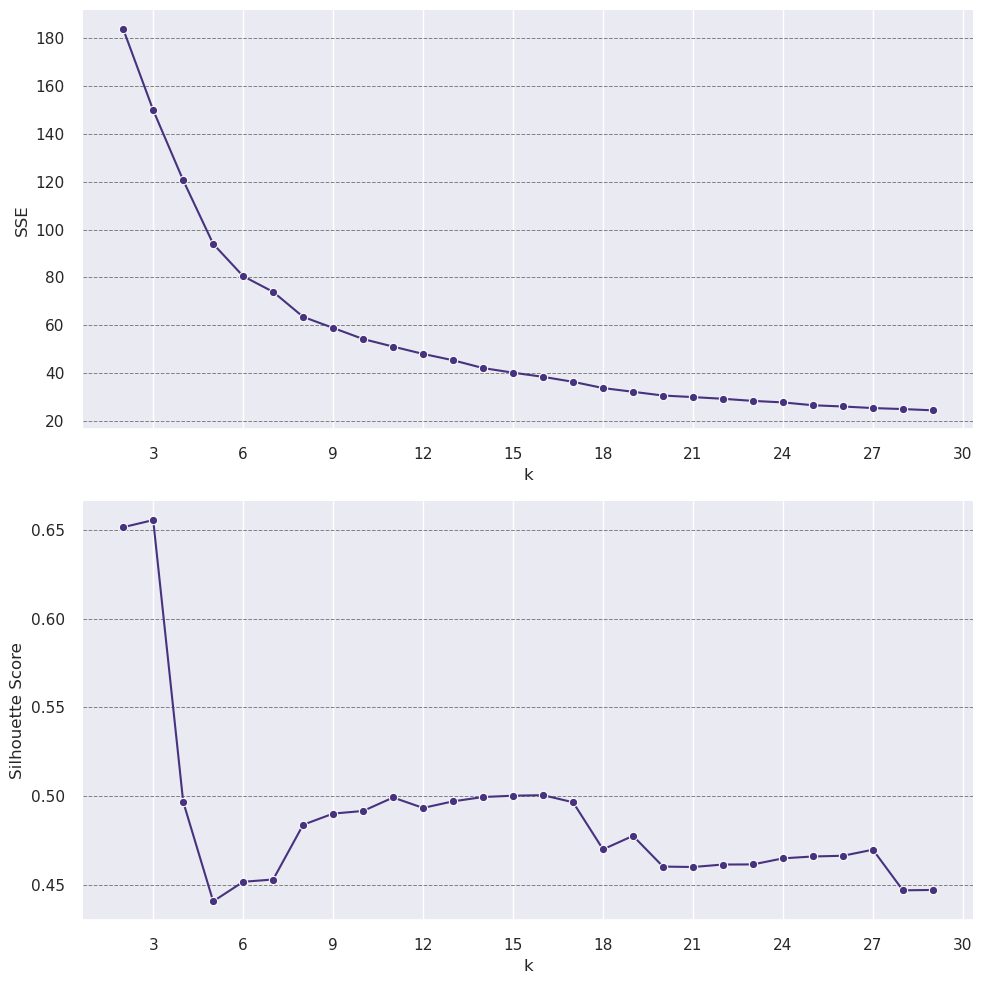

In [26]:
numCol = [
    "criticReviewsTotal",
#    "numRegions",
#    "numVotes",
    "runtimeMinutes",
#    "totalCredits",
#    "totalMedia",
    "totalRecognitions",
    "userReviewsTotal"
]

sns.set_theme(palette='viridis')

# Min-max normalization
scaler = MinMaxScaler()
_df = df[numCol]
df_Z = scaler.fit_transform(_df)

# Liste per memorizzare SSE, Silhouette Score e numero di cluster
sse_list = []
sil_list = []
label_list = []

# Calcola la matrice delle distanze
dist = squareform(pdist(df_Z, metric='euclidean'))

# Esegui Bisecting KMeans per diversi valori di k
for k in range(2, 30):
    bkmeans = BisectingKMeans(n_clusters=k, init = 'k-means++', n_init=500, random_state=42)
    bkmeans.fit(df_Z)
    sse = bkmeans.inertia_
    sil = silhouette_score(dist, bkmeans.labels_, metric='precomputed')
    # print k, without newline
    print(k, end=' ') 
    sse_list.append(sse)
    sil_list.append(sil)
    label_list.append(k)

# Visualizza i risultati
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Plot SSE
sns.lineplot(x=label_list, y=sse_list, marker='o', ax=axs[0])
axs[0].set(xlabel='k', ylabel='SSE')

# Plot Silhouette Score
sns.lineplot(x=label_list, y=sil_list, marker='o', ax=axs[1])
axs[1].set(xlabel='k', ylabel='Silhouette Score')

# Configura gli assi
for ax in axs:
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))  # Mostra solo numeri interi sull'asse x
    ax.grid(True, which='both', axis='y', color='gray', linestyle='--', linewidth=0.7)  # Linee grigio chiaro solo sull'asse y
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

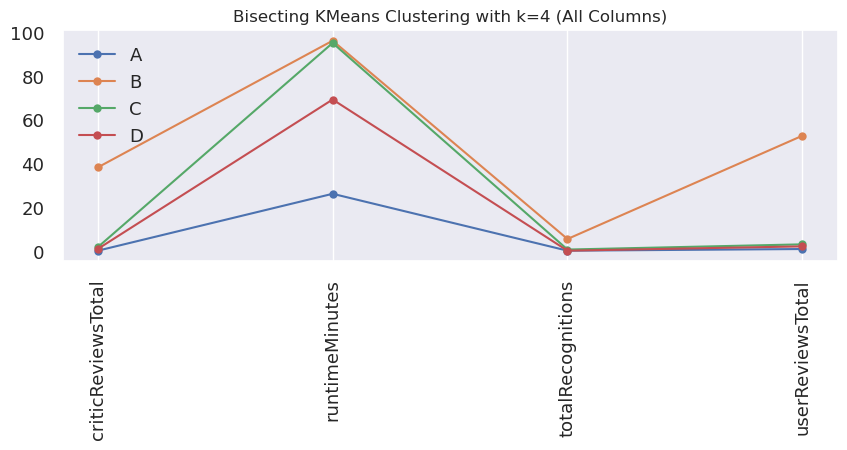

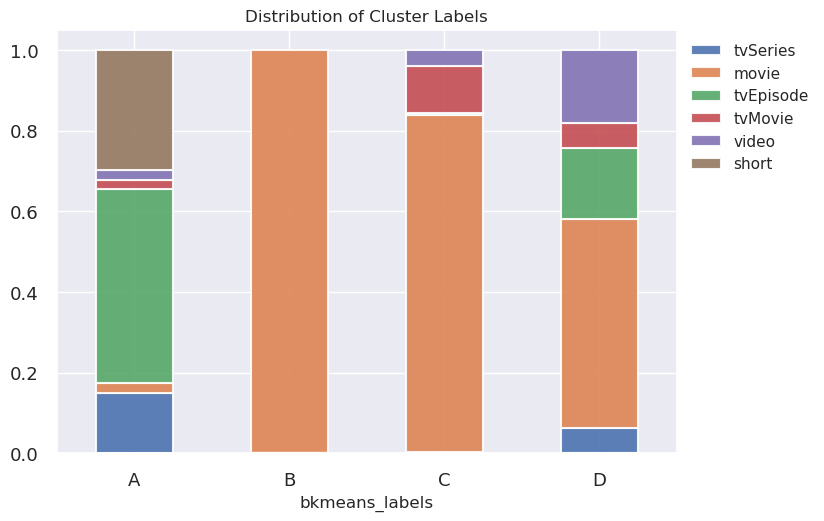

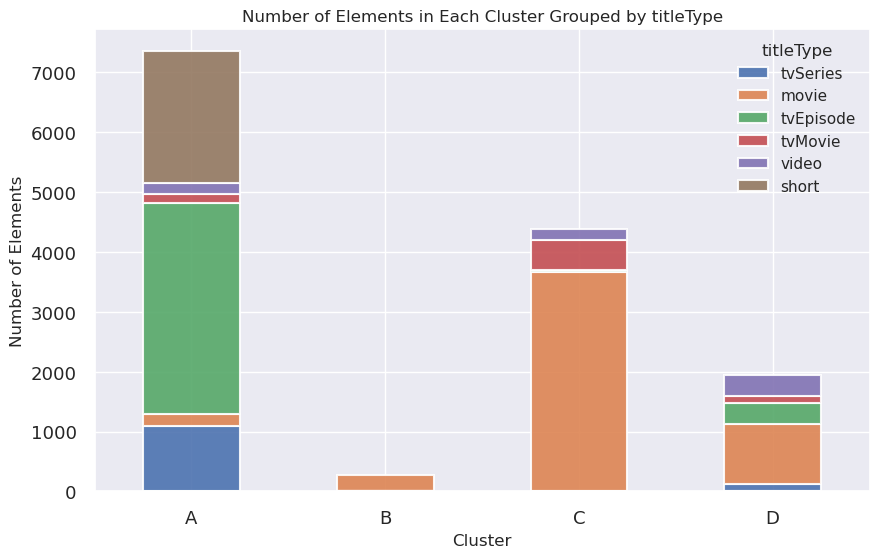

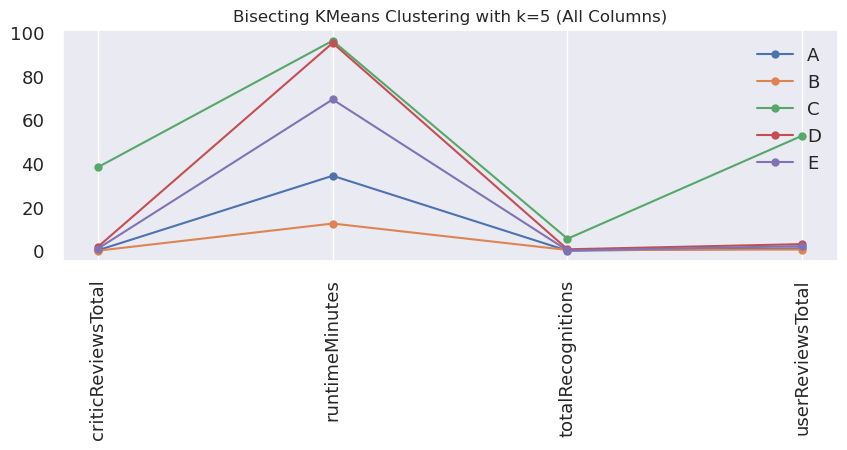

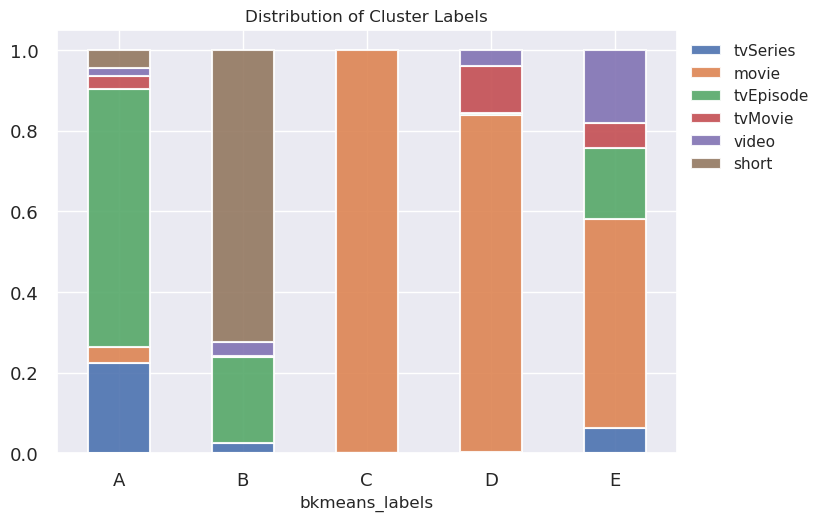

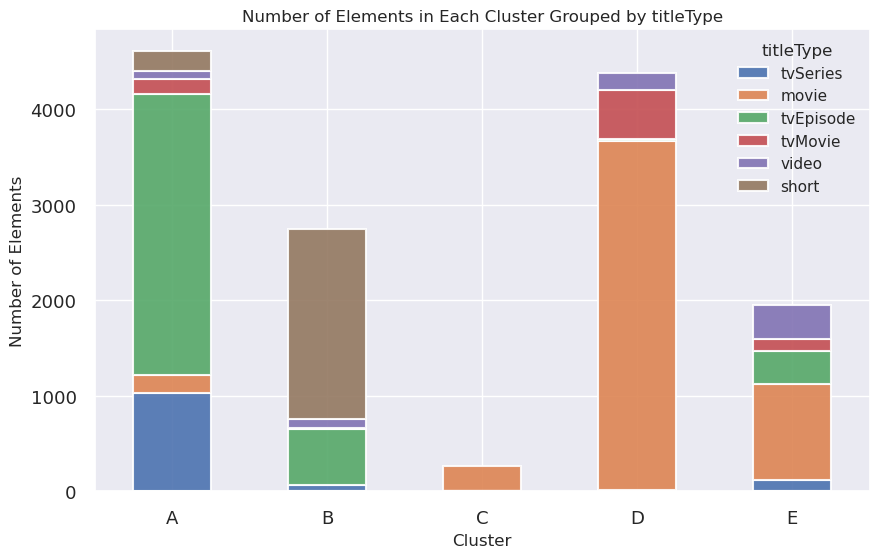

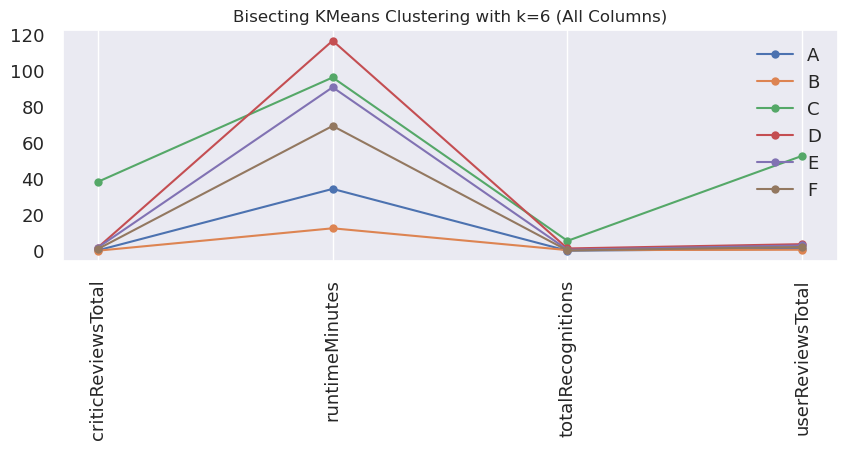

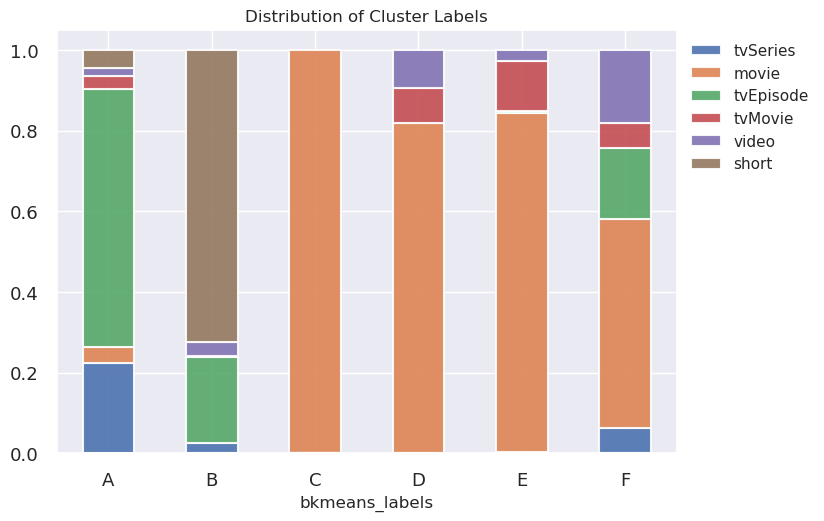

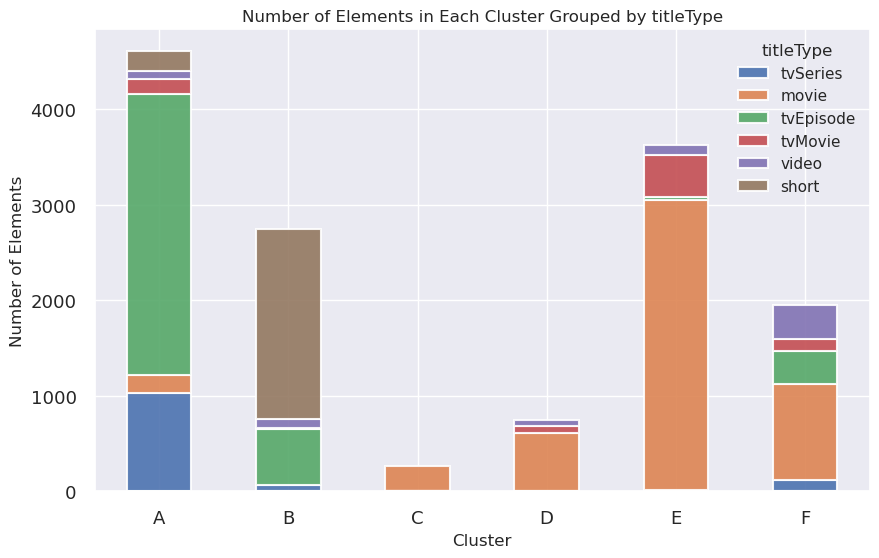

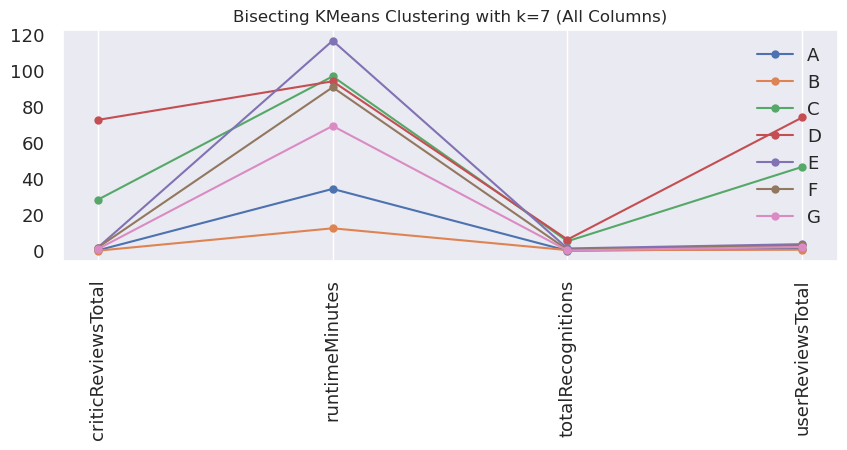

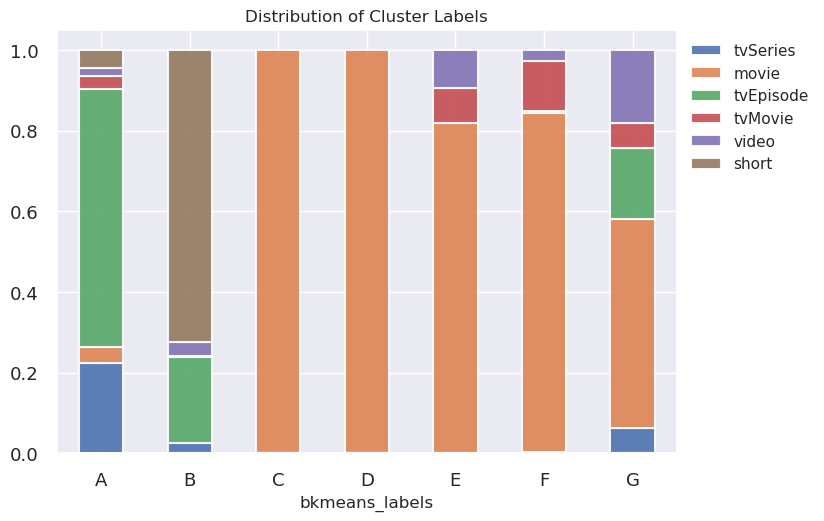

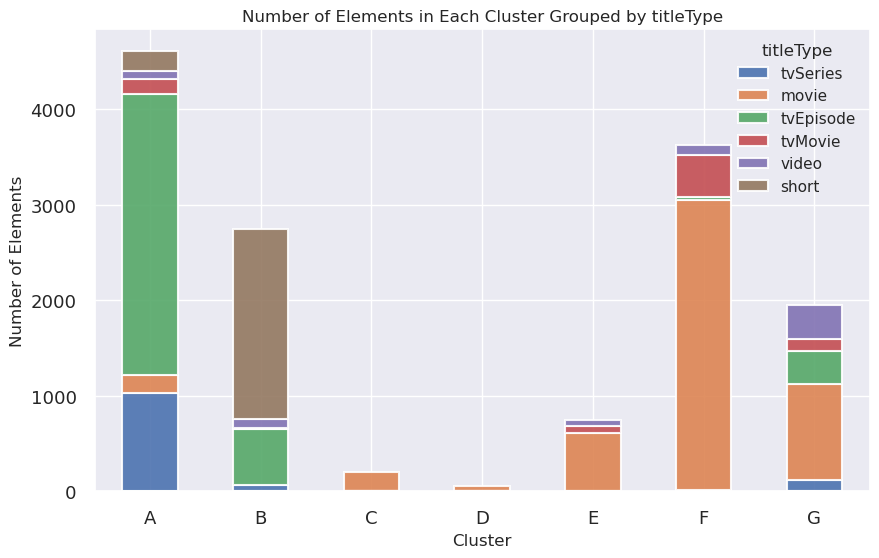

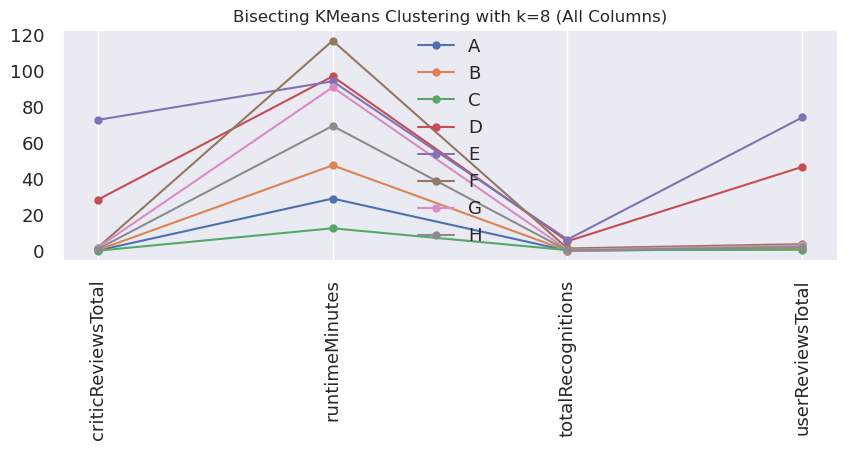

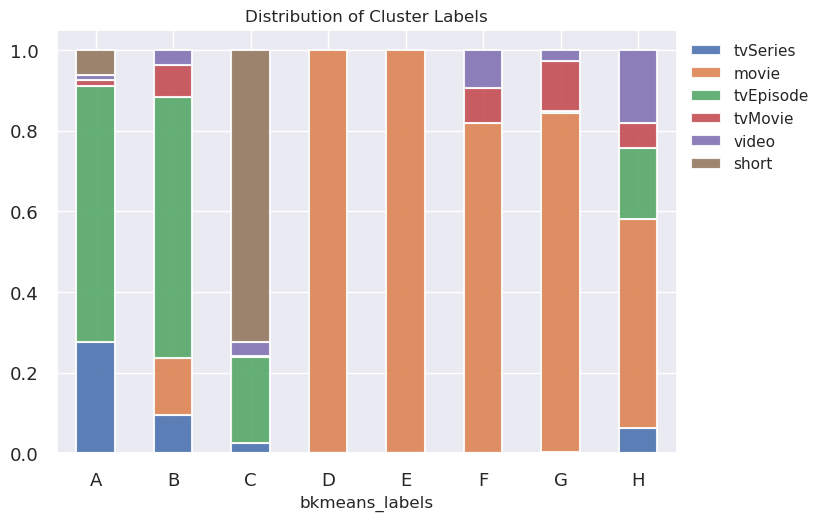

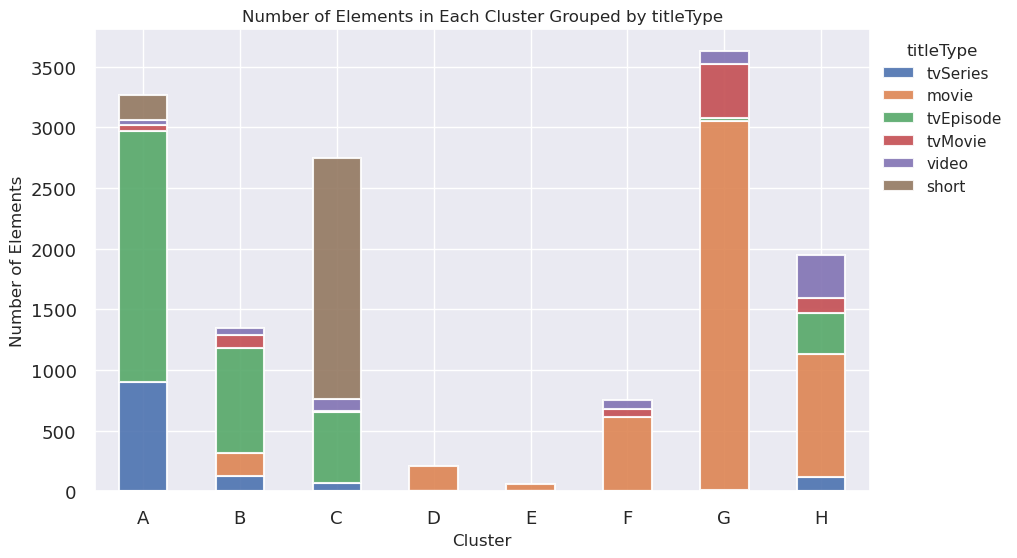

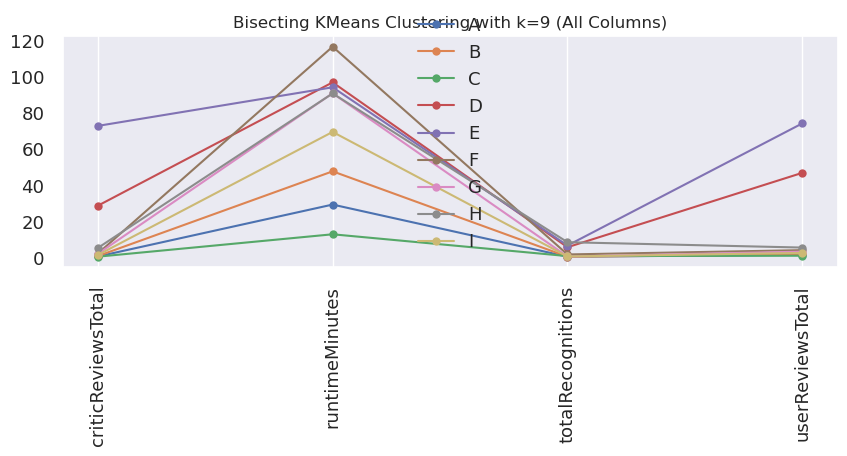

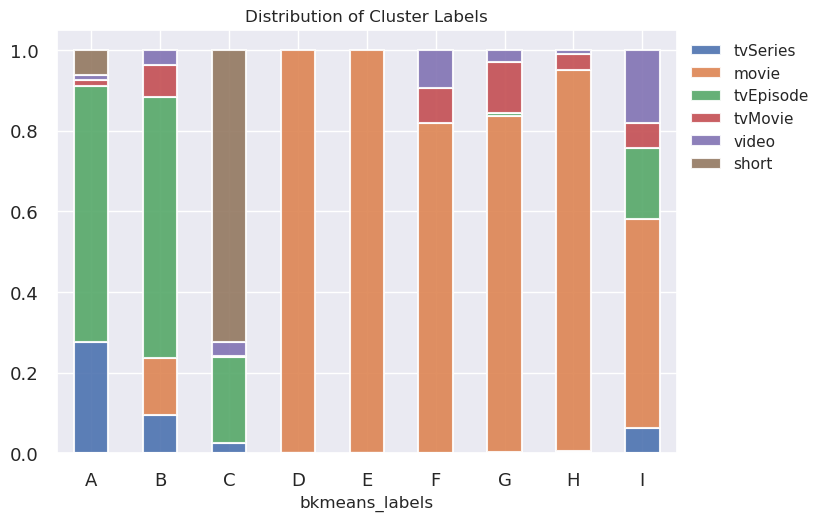

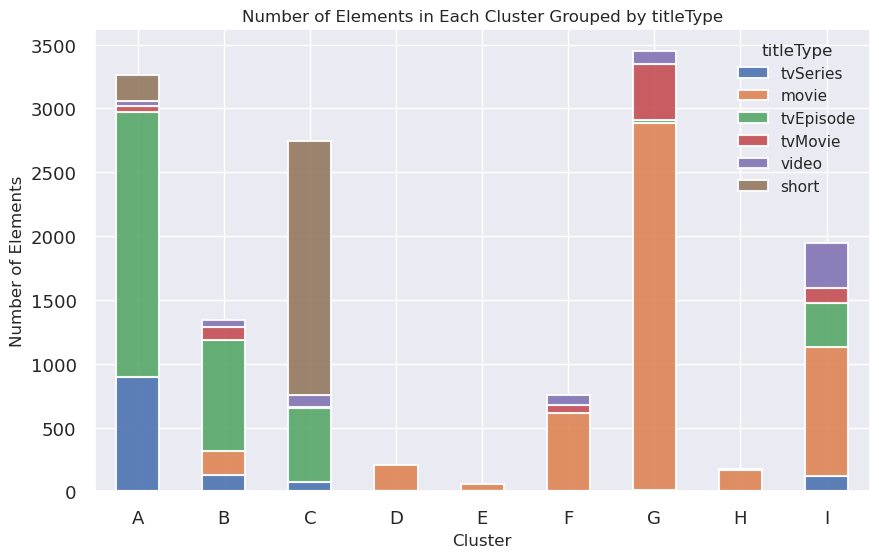

In [28]:
sns.set_theme()
plot_bisecting_kmeans_clusters(_df[numCol], 4, df[col])
plot_bisecting_kmeans_clusters(_df[numCol], 5, df[col])

plot_bisecting_kmeans_clusters(_df[numCol], 6, df[col])

plot_bisecting_kmeans_clusters(_df[numCol], 7, df[col])

plot_bisecting_kmeans_clusters(_df[numCol], 8, df[col])

plot_bisecting_kmeans_clusters(_df[numCol], 9, df[col])